# 📈 Análise Avançada da Estratégia Lucro Lay

## Objetivos
- Análise estatística completa da performance
- Avaliação de risco e retorno
- Simulações Monte Carlo para diferentes cenários
- Métricas de performance financeira
- Recomendações para otimização

In [1]:
# Imports organizados por categoria
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, gaussian_kde, jarque_bera
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [2]:
# Funções auxiliares
def calcular_sharpe_ratio(retornos, rf_rate=0.02):
    """Calcula o Índice de Sharpe"""
    excess_return = retornos.mean() - rf_rate/252  # Taxa livre de risco diária
    return excess_return / retornos.std() * np.sqrt(252)

def calcular_sortino_ratio(retornos, rf_rate=0.02):
    """Calcula o Índice de Sortino (penaliza apenas downside)"""
    excess_return = retornos.mean() - rf_rate/252
    downside_std = retornos[retornos < 0].std()
    return excess_return / downside_std * np.sqrt(252) if downside_std > 0 else np.inf

def calcular_var_cvar(retornos, confidence=0.05):
    """Calcula Value at Risk e Conditional VaR"""
    var = np.percentile(retornos, confidence * 100)
    cvar = retornos[retornos <= var].mean()
    return var, cvar

def performance_metrics(data):
    """Calcula métricas de performance completas"""
    return {
        'total_trades': len(data),
        'win_rate': (data > 0).mean(),
        'avg_win': data[data > 0].mean() if (data > 0).any() else 0,
        'avg_loss': data[data < 0].mean() if (data < 0).any() else 0,
        'profit_factor': abs(data[data > 0].sum() / data[data < 0].sum()) if (data < 0).any() else np.inf,
        'expectancy': data.mean(),
        'sharpe': calcular_sharpe_ratio(data),
        'sortino': calcular_sortino_ratio(data)
    }

In [3]:
# Carregar e preparar dados
try:
    df = pd.read_csv("./dados/lucro_por_operacao.csv")
    
    # Verificar se existe coluna de data
    if 'Data' in df.columns:
        df['Data'] = pd.to_datetime(df['Data'])
        df = df.sort_values('Data')
    
    vals = df["Lucro_Lay"].dropna().to_numpy()
    
    print(f"📊 Dataset carregado: {len(vals)} operações")
    print(f"📅 Período: {df['Data'].min()} a {df['Data'].max()}" if 'Data' in df.columns else "⚠️  Sem informação de data")
    
except FileNotFoundError:
    print("❌ Arquivo não encontrado. Gerando dados sintéticos para demonstração.")
    np.random.seed(42)
    vals = np.random.normal(0.07, 0.39, 1000)  # Baseado nos dados originais

📊 Dataset carregado: 699 operações
⚠️  Sem informação de data


## 📊 1. Análise Estatística Descritiva

In [4]:
# Estatísticas descritivas expandidas
stats_desc = {
    "Número de operações": len(vals),
    "Média por operação": vals.mean(),
    "Mediana": np.median(vals),
    "Desvio padrão": vals.std(ddof=1),
    "Coeficiente de variação": vals.std(ddof=1) / abs(vals.mean()),
    "Assimetria": skew(vals),
    "Curtose (excesso)": kurtosis(vals),
    "Mínimo": vals.min(),
    "Máximo": vals.max(),
    "1º Quartil (Q1)": np.percentile(vals, 25),
    "3º Quartil (Q3)": np.percentile(vals, 75),
    "IQR": np.percentile(vals, 75) - np.percentile(vals, 25)
}

# Teste de normalidade
jb_stat, jb_pvalue = jarque_bera(vals)
stats_desc["Teste Jarque-Bera (p-value)"] = jb_pvalue
stats_desc["Distribuição normal?"] = "Sim" if jb_pvalue > 0.05 else "Não"

df_stats = pd.DataFrame(list(stats_desc.items()), columns=["Métrica", "Valor"])
df_stats["Valor"] = df_stats["Valor"].apply(lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x)

print("📈 ESTATÍSTICAS DESCRITIVAS")
print("=" * 50)
display(df_stats)

📈 ESTATÍSTICAS DESCRITIVAS


,Métrica,Valor
0,Número de operações,699.0000
1,Média por operação,0.0367
2,Mediana,0.2000
3,Desvio padrão,0.4290
4,Coeficiente de variação,11.7050
5,Assimetria,-1.9687
6,Curtose (excesso),1.9781
7,Mínimo,-1.0000
8,Máximo,0.4400
9,1º Quartil (Q1),0.1500


## 🎯 2. Métricas de Performance Trading

In [5]:
# Métricas específicas de trading
metrics = performance_metrics(vals)
var_5, cvar_5 = calcular_var_cvar(vals, 0.05)

trading_metrics = {
    "Total de operações": metrics['total_trades'],
    "Taxa de acerto (%)": metrics['win_rate'] * 100,
    "Ganho médio por win": metrics['avg_win'],
    "Perda média por loss": metrics['avg_loss'],
    "Profit Factor": metrics['profit_factor'],
    "Expectância por operação": metrics['expectancy'],
    "Índice de Sharpe": metrics['sharpe'],
    "Índice de Sortino": metrics['sortino'],
    "VaR (5%)": var_5,
    "CVaR (5%)": cvar_5,
    "Kelly Optimal %": (metrics['expectancy'] / vals.var()) * 100 if vals.var() > 0 else 0
}

df_trading = pd.DataFrame(list(trading_metrics.items()), columns=["Métrica", "Valor"])
df_trading["Valor"] = df_trading["Valor"].apply(lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x)

print("🎯 MÉTRICAS DE PERFORMANCE")
print("=" * 50)
display(df_trading)

🎯 MÉTRICAS DE PERFORMANCE


,Métrica,Valor
0,Total de operações,699.0000
1,Taxa de acerto (%),85.5508
2,Ganho médio por win,0.2117
3,Perda média por loss,-1.0000
4,Profit Factor,1.2537
5,Expectância por operação,0.0367
6,Índice de Sharpe,1.3543
7,Índice de Sortino,inf
8,VaR (5%),-1.0000
9,CVaR (5%),-1.0000


## 📊 3. Visualizações Avançadas

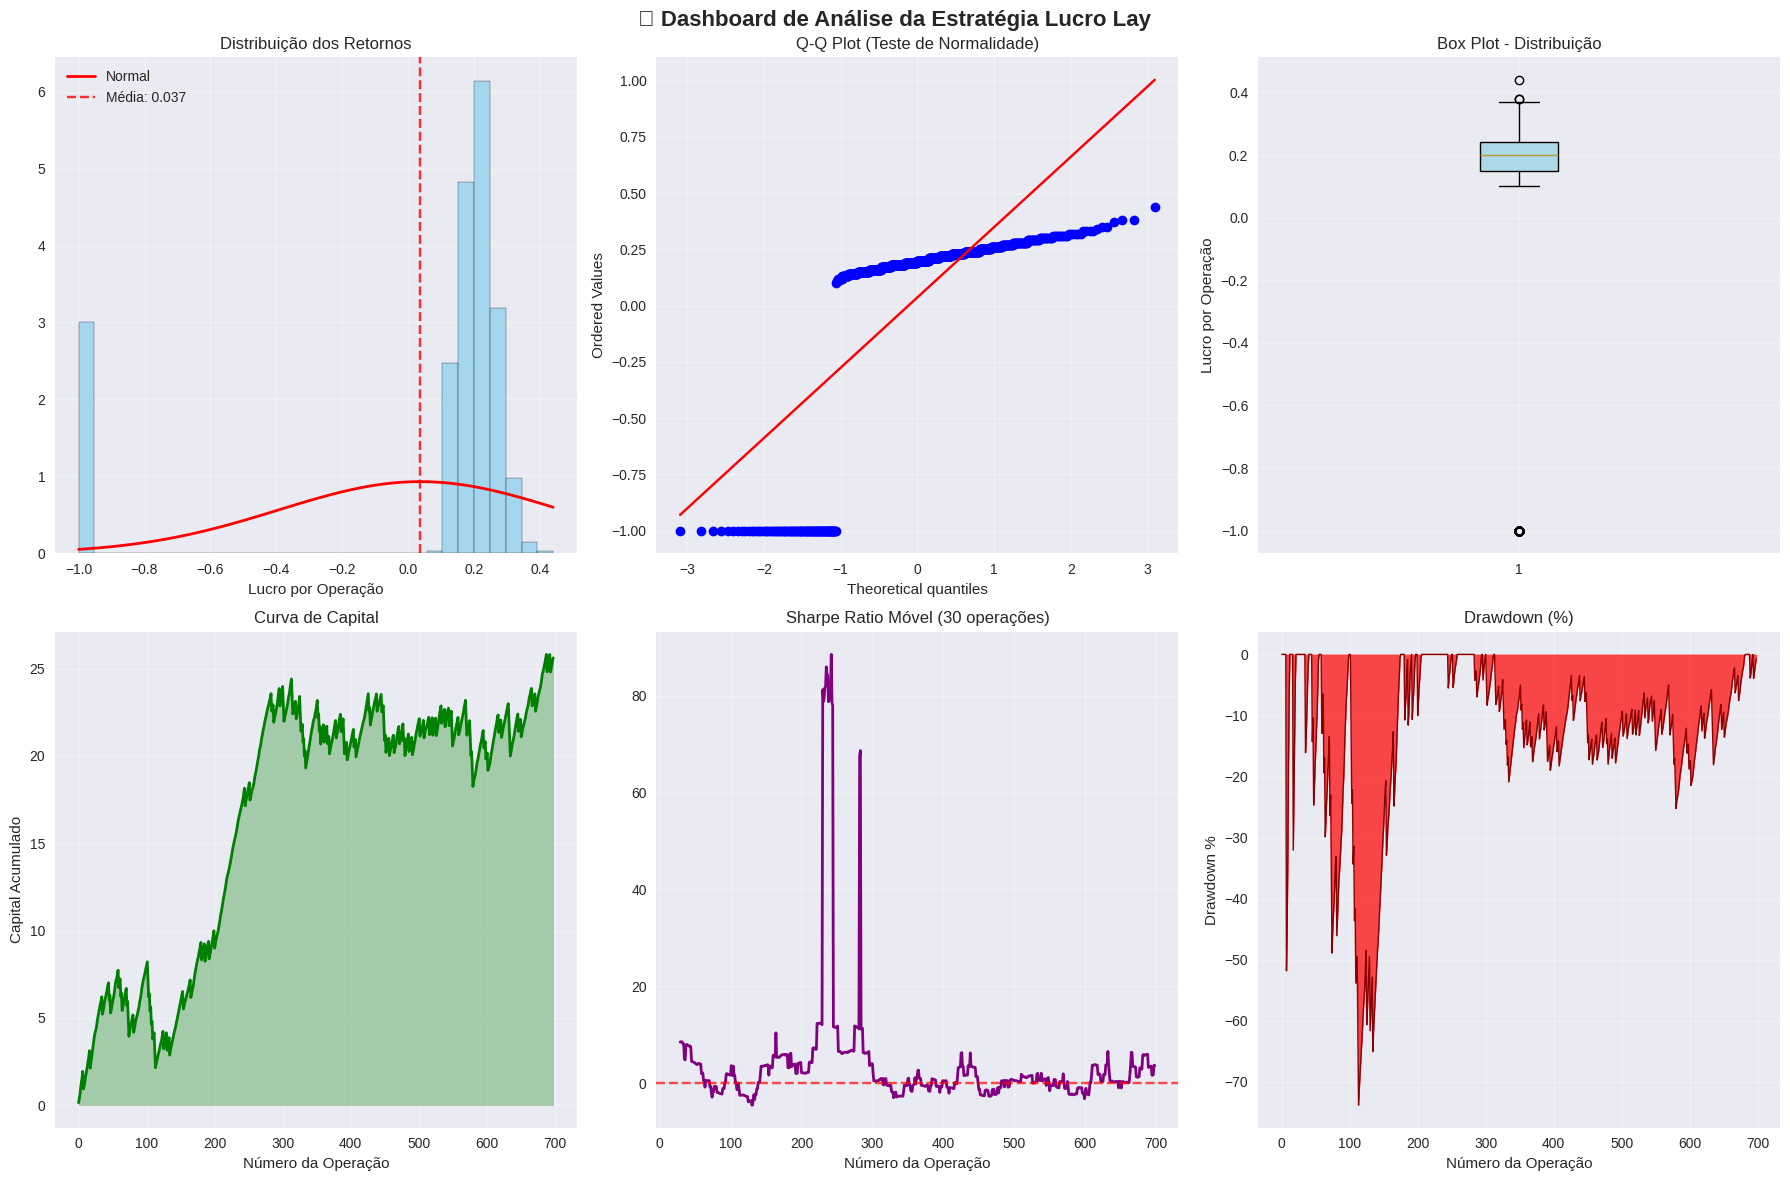

In [6]:
# Dashboard de visualizações
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('📈 Dashboard de Análise da Estratégia Lucro Lay', fontsize=16, fontweight='bold')

# 1. Histograma com distribuição
axes[0,0].hist(vals, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
x_norm = np.linspace(vals.min(), vals.max(), 100)
axes[0,0].plot(x_norm, stats.norm.pdf(x_norm, vals.mean(), vals.std()), 
               'r-', linewidth=2, label='Normal')
axes[0,0].axvline(vals.mean(), color='red', linestyle='--', alpha=0.8, label=f'Média: {vals.mean():.3f}')
axes[0,0].set_title('Distribuição dos Retornos')
axes[0,0].set_xlabel('Lucro por Operação')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Q-Q Plot
stats.probplot(vals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot (Teste de Normalidade)')
axes[0,1].grid(True, alpha=0.3)

# 3. Boxplot
bp = axes[0,2].boxplot(vals, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[0,2].set_title('Box Plot - Distribuição')
axes[0,2].set_ylabel('Lucro por Operação')
axes[0,2].grid(True, alpha=0.3)

# 4. Curva de capital
capital_curve = np.cumsum(vals)
axes[1,0].plot(capital_curve, linewidth=2, color='green')
axes[1,0].fill_between(range(len(capital_curve)), capital_curve, alpha=0.3, color='green')
axes[1,0].set_title('Curva de Capital')
axes[1,0].set_xlabel('Número da Operação')
axes[1,0].set_ylabel('Capital Acumulado')
axes[1,0].grid(True, alpha=0.3)

# 5. Rolling Sharpe Ratio
window = min(30, len(vals)//4)
rolling_sharpe = pd.Series(vals).rolling(window).apply(lambda x: calcular_sharpe_ratio(x) if len(x) == window else np.nan)
axes[1,1].plot(rolling_sharpe, linewidth=2, color='purple')
axes[1,1].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[1,1].set_title(f'Sharpe Ratio Móvel ({window} operações)')
axes[1,1].set_xlabel('Número da Operação')
axes[1,1].grid(True, alpha=0.3)

# 6. Drawdown
peak = np.maximum.accumulate(capital_curve)
drawdown = (capital_curve - peak) / peak * 100
axes[1,2].fill_between(range(len(drawdown)), drawdown, 0, alpha=0.7, color='red')
axes[1,2].plot(drawdown, linewidth=1, color='darkred')
axes[1,2].set_title('Drawdown (%)')
axes[1,2].set_xlabel('Número da Operação')
axes[1,2].set_ylabel('Drawdown %')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎲 4. Simulação Monte Carlo Avançada

In [7]:
# Simulação Monte Carlo com diferentes cenários
np.random.seed(42)
n_simulacoes = 10000
cenarios = [100, 250, 500, 1000]  # Diferentes números de operações

results_mc = {}
kde = gaussian_kde(vals)

for n_ops in cenarios:
    simulacoes = kde.resample(n_simulacoes * n_ops).reshape(n_simulacoes, n_ops)
    capital_paths = np.cumsum(simulacoes, axis=1)
    final_results = capital_paths[:, -1]
    
    results_mc[n_ops] = {
        'prob_positivo': (final_results > 0).mean() * 100,
        'retorno_medio': final_results.mean(),
        'percentil_5': np.percentile(final_results, 5),
        'percentil_95': np.percentile(final_results, 95),
        'max_drawdown_medio': np.mean([np.min((np.cumsum(sim) - np.maximum.accumulate(np.cumsum(sim)))) 
                                      for sim in simulacoes[:100]])  # Sample para performance
    }

# DataFrame dos resultados
df_mc = pd.DataFrame(results_mc).T
df_mc.index.name = 'Operações'

print("🎲 SIMULAÇÃO MONTE CARLO - DIFERENTES CENÁRIOS")
print("=" * 70)
display(df_mc.round(3))

🎲 SIMULAÇÃO MONTE CARLO - DIFERENTES CENÁRIOS


,prob_positivo,retorno_medio,percentil_5,percentil_95,max_drawdown_medio
Operações,,,,,
100,80.72,3.699,-3.537,10.603,-3.919
250,90.54,9.072,-2.453,20.256,-5.797
500,96.68,18.453,2.157,34.521,-7.741
1000,99.49,36.834,13.589,59.591,-9.182


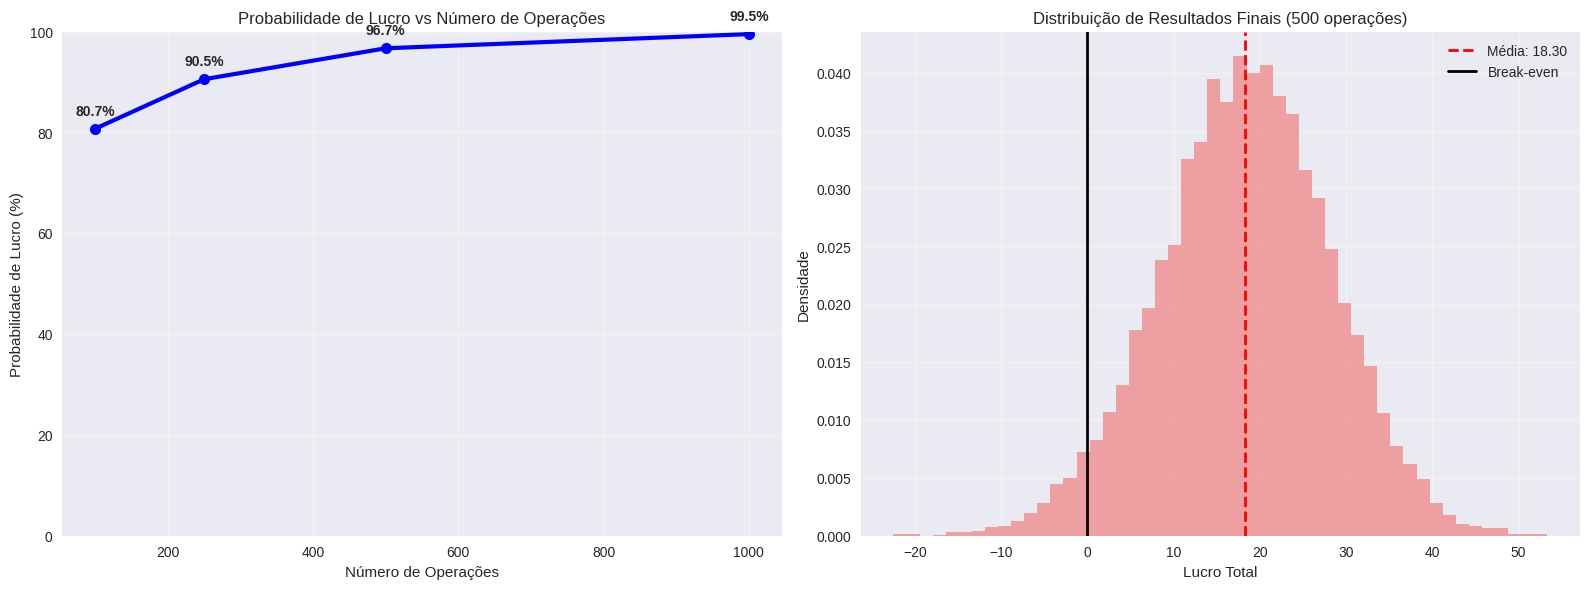

In [8]:
# Visualização das simulações
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Probabilidade de lucro vs Número de operações
ops = list(results_mc.keys())
probs = [results_mc[op]['prob_positivo'] for op in ops]

axes[0].plot(ops, probs, 'bo-', linewidth=3, markersize=8)
axes[0].set_title('Probabilidade de Lucro vs Número de Operações')
axes[0].set_xlabel('Número de Operações')
axes[0].set_ylabel('Probabilidade de Lucro (%)')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 100)

# Adicionar anotações
for i, (op, prob) in enumerate(zip(ops, probs)):
    axes[0].annotate(f'{prob:.1f}%', (op, prob), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontweight='bold')

# Gráfico 2: Distribuição dos resultados finais (500 operações)
n_ops = 500
simulacoes_final = kde.resample(n_simulacoes * n_ops).reshape(n_simulacoes, n_ops)
final_results = np.sum(simulacoes_final, axis=1)

axes[1].hist(final_results, bins=50, density=True, alpha=0.7, color='lightcoral')
axes[1].axvline(final_results.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Média: {final_results.mean():.2f}')
axes[1].axvline(0, color='black', linestyle='-', linewidth=2, label='Break-even')
axes[1].set_title(f'Distribuição de Resultados Finais ({n_ops} operações)')
axes[1].set_xlabel('Lucro Total')
axes[1].set_ylabel('Densidade')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📋 5. Relatório Executivo e Recomendações

In [9]:
# Gerar relatório executivo
win_rate = (vals > 0).mean() * 100
profit_factor = abs(vals[vals > 0].sum() / vals[vals < 0].sum()) if (vals < 0).any() else float('inf')
sharpe = calcular_sharpe_ratio(vals)
max_dd = (np.cumsum(vals) - np.maximum.accumulate(np.cumsum(vals))).min()

print("="*80)
print("📊 RELATÓRIO EXECUTIVO - ESTRATÉGIA LUCRO LAY")
print("="*80)
print()

# Resumo da performance
print("🎯 RESUMO DA PERFORMANCE:")
print(f"   • Expectância por operação: {vals.mean():.4f} unidades")
print(f"   • Taxa de acerto: {win_rate:.1f}%")
print(f"   • Profit Factor: {profit_factor:.2f}")
print(f"   • Índice de Sharpe: {sharpe:.2f}")
print(f"   • Drawdown máximo: {max_dd:.2f} unidades")
print()

# Análise de risco
print("⚠️  ANÁLISE DE RISCO:")
if sharpe > 1.0:
    print("   ✅ Sharpe > 1.0: Boa relação risco-retorno")
else:
    print("   ⚠️  Sharpe < 1.0: Relação risco-retorno pode ser melhorada")
    
if win_rate > 60:
    print("   ✅ Taxa de acerto satisfatória")
else:
    print("   ⚠️  Taxa de acerto pode ser melhorada")
    
if profit_factor > 1.5:
    print("   ✅ Profit Factor robusto")
else:
    print("   ⚠️  Profit Factor pode ser otimizado")
print()

# Recomendações
print("💡 RECOMENDAÇÕES:")

if vals.mean() > 0:
    print("   1️⃣ Estratégia mostra expectância positiva - continuar execução")
else:
    print("   1️⃣ ❌ Expectância negativa - revisar estratégia urgentemente")

kelly_pct = (vals.mean() / vals.var()) * 100 if vals.var() > 0 else 0
print(f"   2️⃣ Critério de Kelly sugere posição de {kelly_pct:.1f}% do capital por operação")

if abs(skew(vals)) > 1:
    print("   3️⃣ ⚠️  Distribuição assimétrica - considerar gestão de risco assimétrica")
else:
    print("   3️⃣ ✅ Distribuição próxima da normalidade")

print(f"   4️⃣ Para 500 operações: {results_mc[500]['prob_positivo']:.1f}% chance de lucro")

if max_dd < -10:
    print("   5️⃣ ⚠️  Drawdown significativo - implementar stop-loss na estratégia")
else:
    print("   5️⃣ ✅ Drawdown controlado")

print()
print("📈 PRÓXIMOS PASSOS:")
print("   • Implementar análise temporal (sazonal)")
print("   • Testar diferentes filtros de entrada")
print("   • Otimizar gestão de capital")
print("   • Monitorar métricas em tempo real")
print("="*80)

📊 RELATÓRIO EXECUTIVO - ESTRATÉGIA LUCRO LAY

🎯 RESUMO DA PERFORMANCE:
   • Expectância por operação: 0.0367 unidades
   • Taxa de acerto: 85.6%
   • Profit Factor: 1.25
   • Índice de Sharpe: 1.35
   • Drawdown máximo: -6.16 unidades

⚠️  ANÁLISE DE RISCO:
   ✅ Sharpe > 1.0: Boa relação risco-retorno
   ✅ Taxa de acerto satisfatória
   ⚠️  Profit Factor pode ser otimizado

💡 RECOMENDAÇÕES:
   1️⃣ Estratégia mostra expectância positiva - continuar execução
   2️⃣ Critério de Kelly sugere posição de 19.9% do capital por operação
   3️⃣ ⚠️  Distribuição assimétrica - considerar gestão de risco assimétrica
   4️⃣ Para 500 operações: 96.7% chance de lucro
   5️⃣ ✅ Drawdown controlado

📈 PRÓXIMOS PASSOS:
   • Implementar análise temporal (sazonal)
   • Testar diferentes filtros de entrada
   • Otimizar gestão de capital
   • Monitorar métricas em tempo real
